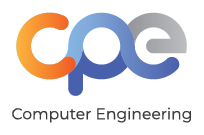

# CPE112: Programming with Data Structures
# Assignment3: Stacks Queues and Deques

### Implementation of the Stack ADT.

**Stack ADT**  
A stack is a data structure that stores a linear collection of items with access limited to a last-in first-out (LIFO) order. Adding and removing items is restricted to one end known as the top of the stack. An empty stack is one containing no items.
| properties/methods    | description    |
| --- | --- |  
| __Stack()__: | Creates a new empty stack.|
| __isEmpty()__: |Returns a Boolean value indicating if the stack is empty.|
| __length()__: |Returns the number of items in the stack.|
| __pop()__: |Removes and returns the top item of the stack, if the stack is not empty. Items cannot be popped from an empty stack. The next item on the stack becomes the new top item.|
| __peek()__: |Returns a reference to the item on top of a non-empty stack without removing it. Peeking, which cannot be done on an empty stack, does not modify the stack contents.|
| __push(item)__: | Adds the given item to the top of the stack.|
| __\_\_repr()\_\___:| Represent the values of elements keep in stack |

## <span style="color:red"> Practice1: Implement the Stack class with Array class</span>

In [1]:
class Stack:
    def __init__(self):
        self._theItems = list()

    def isEmpty(self):
        return len(self) == 0
    
    def __len__(self):
        return len(self._theItems)

    def peek(self):
        assert not self.isEmpty(), "Can't peek empty stack"
        return self._theItems[-1]
    
    def pop(self):
        assert not self.isEmpty(), "can't pop empty pop"
        return self._theItems.pop()
    
    def push(self, item):
        self._theItems.append(item)

    def __repr__(self):
        s = '<--'
        s = s.join([str(x) for x in self._theItems])
        return s

---

> Then try to test the stacks and run all methods

In [2]:
S = Stack()

In [3]:
S.push(50)
print(S.peek())

50


In [4]:
S.push(100)
S.pop()

100

In [5]:
S

50

## Implement With ARRAY

In [6]:
# Implement with array
import ctypes

class Array:
    def __init__(self, size):
        self._size = size
        PyArrayType = ctypes.py_object * size
        self._element = PyArrayType()
        self.clear(None)
    
    def __getitem__(self, index):
        return self._element[index]
    
    def __setitem__(self, index, value):
        self._element[index] = value

    def __len__(self):
        return (self._size)
    
    def clear(self, value):
        for index in range(self._size):
            self._element[index] = value

In [7]:
class Stack:
    def __init__(self, size):
        self._element = Array(size)
        self._capacity = size
        self._top = 0

    def isFull(self):
        return self._top == self._capacity
    
    def isEmpty(self):
        return self._top == 0
    
    def __len__(self):
        return self._top

    def pop(self):
        assert not self.isEmpty(), "Cannot pop from empty stack"
        self._top -= 1
        return self._element[self._top]
    
    def peek(self):
        assert not self.isEmpty(), "Cannot peek at an empty stack"
        return self._element[self._top - 1]
    
    def push(self, item):
        assert not self.isFull(), "Cant push cause stack is full"
        self._element[self._top] = item
        self._top += 1

    def __repr__(self):
        s = ""
        for item in range(self._top-1, -1, -1):
            s = s + '|' + str(self._element[item]) + "\t|" + '\n'
        s = s+'---------'
        return s

In [8]:
S = Stack(5)

In [9]:
S.push('CPE')
S.push(123)
S.push('HDS')
S.push(2569)

In [10]:
print(S)

|2569	|
|HDS	|
|123	|
|CPE	|
---------


In [11]:
S.pop()

2569

In [12]:
print(S)

|HDS	|
|123	|
|CPE	|
---------


***

### Implementation of the Queue ADT

**QUEUE ADT**  
A queue is a data structure that a linear collection of items in which access is restricted to a first-in first-out (FIFO) basis. New items are inserted at the back and existing items are removed from the front. The items are maintained in the order in which they are added to the structure.
| properties/methods    | description    |
| --- | --- | 
| __Queue()__: | Creates a new empty queue, which is a queue containing no items.
| __isEmpty()__: | Returns a Boolean value indicating whether the queue is empty.
| __length()__: | Returns the number of items currently in the queue.
| __enqueue(item)__: | Adds the given item to the back of the queue.
| __dequeue()__: | Removes and returns the front item from the queue. An item cannot be dequeued from an empty queue.
| __\_\_repr()\_\___:| Represent the values of elements keep in queue |

## <span style="color:red"> Practice2: Implement the Queue class with Array class</span>

In [13]:
# implement with list
class Queue:
    def __init__(self):
        self._qList = list()

    def isEmpty(self):
        return len(self) == 0
    
    def __len__(self):
        return len(self._qList)
    
    def enqueue(self, item):
        self._qList.append(item)
        
    def dequeue(self):
        assert not self.isEmpty(), "Can't dequeue from empty queue"
        return self._qList.pop(0)

> Try to test and run the queues

In [14]:
Q = Queue()

In [15]:
Q.enqueue(50)
Q.dequeue()

50

## Implement with ARRAY

In [16]:
# Implement with array
import ctypes

class Array:
    def __init__(self, size):
        self._size = size
        PyArrayType = ctypes.py_object * size
        self._element = PyArrayType()
        self.clear(None)
    
    def __getitem__(self, index):
        return self._element[index]
    
    def __setitem__(self, index, value):
        self._element[index] = value

    def __len__(self):
        return (self._size)
    
    def clear(self, value):
        for index in range(self._size):
            self._element[index] = value

In [17]:
class Queue:
    def __init__(self, size):
        self._element = Array(size)
        self._capacity = size
        self._tail = 0

    def isFull(self):
        return self._tail == self._capacity
    
    def isEmpty(self):
        return self._tail == 0
    
    def __len__(self):
        return self._tail
    
    def enqueue(self, item):
        assert not self.isFull(), "Cant enqueue cause queue is full"
        self._element[self._tail] = item
        self._tail += 1

    def dequeue(self):
        assert not self.isEmpty(), "Cannot pop from empty stack"
        item = self._element[0]
        for i in range(len(self)-1): # วน loop shift ค่า ให้ค่าก่อนหน้ามีค่าเท่าตัวต่อไป โดยการวนตำแหน่งสลับที่ i และ i+1
            self._element[i] = self._element[i+1]
        self._element[self._tail-1] = None # ทำให้ item ตัวสุดท้ายของ queue มีค่าเป็น None
        self._tail -= 1
        return item
    
    def __repr__(self):
        s = '<--'
        s = s.join([str(x) for x in self._element])
        return s

In [18]:
q = Queue(5)

In [19]:
q.enqueue('CPE')
q.enqueue('112')
q.enqueue('HDS')
q.enqueue('2569')
print(q)

CPE<--112<--HDS<--2569<--None


In [20]:
q.dequeue()
print(q)

112<--HDS<--2569<--None<--None


---

### Implementation of the Circular Queue with an array

__CQueue ADT__ <br>
A Circular queue is a data structure that a linear collection of items in which access is restricted to a first-in first-out (FIFO) basis. However a circular queue is the extended version of a regular queue where the last element is connected to the first element. Thus forming a circle-like structure. New items are inserted at the back-index position and front items are removed from the front-index position.
| properties/methods    | description    |
| --- | --- | 
| __CQueue()__: | Creates a new empty circular queue, which a circular array is used to contain the items.
| __isEmpty()__: | Returns a Boolean value indicating whether the circular queue is empty.
| __isFull()__: | Returns a Boolean value indicating whether the circular queue is full.
| __length()__: | Returns the number of items currently collected in the circular queue.
| __enqueue(item)__: | Adds the given item to the back-index position of the circular queue.
| __dequeue()__: | Removes and returns the front item from the circular queue. An item cannot be dequeued from an empty circular queue.
| __\_\_repr()\_\___:| Represent the values of elements keep in circular queue |

## <span style="color:red"> Practice3: Implement the CQueue class with Circular Array</span>

In [21]:
import ctypes

class Array:
    def __init__(self, size):
        self._size = size
        PyArray = ctypes.py_object * size
        self._element = PyArray()
        self.clear(None)
    
    def __getitem__(self, index):
        return self._element[index]
    
    def __setitem__(self, index, value):
        self._element[index] = value

    def __len__(self):
        return (self._size)
    
    def clear(self, value):
        for index in range(self._size):
            self._element[index] = value

In [22]:
class CQueue:
    def __init__(self,  maxSize):
        self._count = 0
        self._front = 0
        self._back = maxSize - 1
        self._qArray = Array(maxSize)

    def enqueue(self, item):
        assert not self.isFull(), "Can't enqueue cause full queue"
        maxSize = len(self._qArray)
        self._back = (self._back + 1) % maxSize #ตัวชี้วงกลมที่ใช้ math หา #มันจะเลื่อนไปในทุกๆเศษ
        self._qArray[self._back] = item
        self._count += 1

    def dequeue(self):
        assert not self.isEmpty(), "Can't enqueue cause full queue"
        item = self._qArray[self._front]
        maxSize = len(self._qArray)
        self._qArray[self._front] = None
        self._front = (self._front + 1) % maxSize
        self._count -= 1
        return item

    def __len__(self):
        return self._count
    
    def isFull(self):
        maxSize = len(self._qArray)
        return self._count == maxSize
    
    def isEmpty(self):
        return self._count == 0
    
    def __repr__(self):
        s = '<--'
        s = s.join([str(x) for x in self._qArray])
        return s

> Try to test and run the Cqueues

In [23]:
cq = CQueue(7)

In [24]:
cq.enqueue('5')
cq.enqueue('10')
cq.enqueue('15')
print(cq)

5<--10<--15<--None<--None<--None<--None


In [25]:
cq.isFull()

False

In [26]:
cq.dequeue()
print(cq)

None<--10<--15<--None<--None<--None<--None


---

### Implementation of the Double-Ended Queue

**Deque ADT**  
A doubled-ended queue is a queue-like data structure that supports insertion and deletion at both the front and the back of the queue.
| properties/methods    | description    |
| --- | --- | 
| __Deque()__: | Create a new empty deque, which no item with in.
| __AddFirst(item)__: | Add an item to the front of deque.
| __AddRear(item)__: | Add an item to the back of deque.
| __DeleteFirst()__: | Remove and return the first item from deque; an error occurs if the deque is empty.
| __DeleteRear()__: | Remove and return the last item from deque; an error occurs if the deque is empty.
| __First()__: | Return (but do not remove) the first item of deque; an error occurs if the deque is empty.
| __Rear()__: | Return (but do not remove) the last item of deque; an error occurs if the deque is empty.
| __isEmpty()__: | Return True if deque does not contain any items.
| __length()__: | Return the number of items in deque.
| __\_\_repr()\_\___:| Represent the values of elements keep in deque |



### Hint:
| Deque Method | Compare to Python List , Stack, Queue |
| --- | --- |
| Deque.addFirst(item) | List.insert(0,item) |
| Deque.addRear(item) |   List.append(item) ,Stack.push(item)|
| Deque.DeleteFirst() | List.pop(0), Queue.dequeue() |
| Deque.DeleteRear()    | List.pop(), Stack.pop() |
| Deque.First() |   List[0] |
| Deque.Rear()  | List[-1] |
| Deque.isEmpty()   | len(List) == 0, Stack.isEmpty(), Queue.isEmpty()|
| len(Deque)    | len(List), len(Stack), len(Queue)  |


### <span style="color:red"> Practice4 </span>: Implement Deque class with Array Class

In [27]:
# Python list implementation

class Deq:
    def __init__(self):
        self._element = list()

    def addFirst(self, item):
        self._element.insert(0,item)
    
    def addRear(self, item):
        self._element.append(item)

    def deleteFirst(self):
        self._element.pop(0)

    def deleteRear(self):
        self._element.pop()

    def isEmpty(self):
        return len(self) == 0 # check equal to, cause we use ==. It's an if statement
    
    def __len__(self):
        return len(self._element)
    
    def __repr__(self):
        s = '<--'
        s = s.join([str(x) for x in self._element])
        return s

> Try to write code for implement a deque

In [28]:
d = Deq()

In [29]:
d.addFirst(1)
print(d)

1


---